# Module 3, Part 3 — Data augmentation

This notebook is the runnable companion to Part 3 of the Module 03 learning
module. It builds the exact two-pipeline structure from the module
(`train_transform` vs. `eval_transform`), then carries out the module's own
"Try it" exercise:

> Run a single image through the training pipeline five separate times and
> confirm the five outputs are visibly different from each other, despite
> coming from the same source image. Run the same image through the
> evaluation pipeline five times and confirm all five outputs are
> identical.

The module's reference code uses `torchvision.transforms` directly:

```python
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet statistics
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
```

This notebook reimplements each of those steps directly with PIL, NumPy,
and torch, in the same order, rather than importing `torchvision`. That
is a workaround for this environment's installed torch/torchvision pairing
(its native operators are not registered correctly, so even `import
torchvision` fails here), not a change in what the pipelines do. On a
machine with a working torchvision install, the code block above is a
drop-in replacement for the `train_transform` / `eval_transform` functions
built below. Runs on CPU in well under a minute.

In [1]:
import torch
import numpy as np
from PIL import Image, ImageEnhance
import random
import matplotlib.pyplot as plt

torch.manual_seed(0)
random.seed(0)
print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cpu


## 0. A stand-in test image

A simple synthetic photo-like image: a light sky-coloured background, a
darker "ground" band, and an off-centre bright square standing in for a
subject. Nothing about the exercise below depends on the image being real;
it only needs to be a normal three-channel colour image.

Image size: (256, 256)  mode: RGB


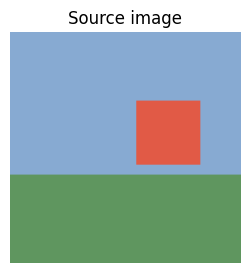

In [2]:
def make_test_image(size=256):
    arr = np.zeros((size, size, 3), dtype=np.uint8)
    arr[:, :] = [135, 170, 210]            # sky
    horizon = int(size * 0.62)
    arr[horizon:, :] = [95, 150, 95]       # ground
    # an off-centre bright square, the "subject"
    top, left, side = int(size * 0.30), int(size * 0.55), int(size * 0.28)
    arr[top:top + side, left:left + side] = [225, 90, 70]
    return Image.fromarray(arr, mode="RGB")


image = make_test_image()
print("Image size:", image.size, " mode:", image.mode)

plt.figure(figsize=(3, 3))
plt.imshow(image)
plt.title("Source image")
plt.axis("off")
plt.show()

## 1. The individual transform steps

Each step below matches the corresponding `torchvision.transforms` class
by name and behaviour: a random crop of a random scale/aspect ratio
resized back to a fixed size, a coin-flip horizontal mirror, and a small
random perturbation of brightness/contrast/saturation. `to_tensor` and
`normalize` are the same fixed, non-random conversion and rescaling
`torchvision.transforms.ToTensor` / `Normalize` perform.

In [3]:
def random_resized_crop(img, output_size=224, scale=(0.5, 1.0), ratio=(3 / 4, 4 / 3)):
    """Matches transforms.RandomResizedCrop: a random-area, random-aspect-ratio
    crop of the image, resized back to a fixed square size."""
    width, height = img.size
    area = width * height

    for _ in range(10):
        target_area = random.uniform(*scale) * area
        log_ratio = (np.log(ratio[0]), np.log(ratio[1]))
        aspect = np.exp(random.uniform(*log_ratio))

        w = int(round((target_area * aspect) ** 0.5))
        h = int(round((target_area / aspect) ** 0.5))

        if 0 < w <= width and 0 < h <= height:
            left = random.randint(0, width - w)
            top = random.randint(0, height - h)
            crop = img.crop((left, top, left + w, top + h))
            return crop.resize((output_size, output_size), Image.BILINEAR)

    # Fallback: a centred square crop if no random candidate fit.
    side = min(width, height)
    left, top = (width - side) // 2, (height - side) // 2
    crop = img.crop((left, top, left + side, top + side))
    return crop.resize((output_size, output_size), Image.BILINEAR)


def random_horizontal_flip(img, p=0.5):
    """Matches transforms.RandomHorizontalFlip."""
    if random.random() < p:
        return img.transpose(Image.FLIP_LEFT_RIGHT)
    return img


def color_jitter(img, brightness=0.2, contrast=0.2, saturation=0.2):
    """Matches transforms.ColorJitter: each factor is drawn uniformly from
    [1 - x, 1 + x] and applied independently."""
    b = random.uniform(1 - brightness, 1 + brightness)
    c = random.uniform(1 - contrast, 1 + contrast)
    s = random.uniform(1 - saturation, 1 + saturation)
    img = ImageEnhance.Brightness(img).enhance(b)
    img = ImageEnhance.Contrast(img).enhance(c)
    img = ImageEnhance.Color(img).enhance(s)
    return img


def to_tensor(img):
    """Matches transforms.ToTensor: HWC uint8 [0, 255] -> CHW float32 [0, 1]."""
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1).contiguous()


def normalize(tensor, mean, std):
    """Matches transforms.Normalize: per-channel (x - mean) / std."""
    mean_t = torch.tensor(mean).view(-1, 1, 1)
    std_t = torch.tensor(std).view(-1, 1, 1)
    return (tensor - mean_t) / std_t


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

## 2. The two pipelines, as functions

`train_transform` chains every random step; `eval_transform` uses only the
two deterministic steps (a fixed resize, then a centre crop) before the
same normalization.

In [4]:
def center_crop(img, output_size):
    width, height = img.size
    left = (width - output_size) // 2
    top = (height - output_size) // 2
    return img.crop((left, top, left + output_size, top + output_size))


def train_transform(img):
    img = random_resized_crop(img, output_size=224)
    img = random_horizontal_flip(img)
    img = color_jitter(img, brightness=0.2, contrast=0.2, saturation=0.2)
    tensor = to_tensor(img)
    return normalize(tensor, IMAGENET_MEAN, IMAGENET_STD)


def eval_transform(img):
    img = img.resize((256, 256), Image.BILINEAR)
    img = center_crop(img, 224)
    tensor = to_tensor(img)
    return normalize(tensor, IMAGENET_MEAN, IMAGENET_STD)


print("train_transform: random_resized_crop -> random_horizontal_flip -> color_jitter -> to_tensor -> normalize")
print("eval_transform:  resize(256)         -> center_crop(224)       -> to_tensor      -> normalize")

train_transform: random_resized_crop -> random_horizontal_flip -> color_jitter -> to_tensor -> normalize
eval_transform:  resize(256)         -> center_crop(224)       -> to_tensor      -> normalize


## 3. Try it: five passes through the training pipeline

The module's exercise, worked out here. We run the same source image
through `train_transform` five separate times and display each result.
Watch the crop framing, the flip, and the colour shift change from one
pass to the next.

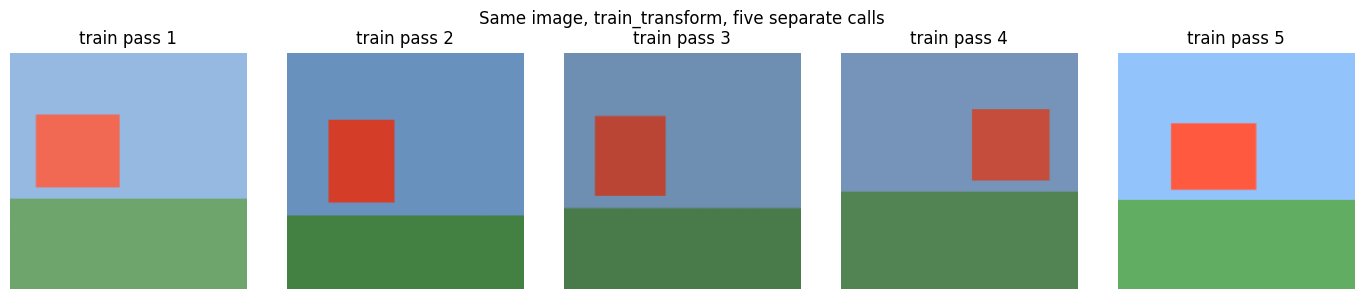

Output tensor shape (each pass): (3, 224, 224)


In [5]:
def to_displayable(tensor):
    """Undo ImageNet normalization so the tensor can be shown as an image."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    unnormalized = tensor * std + mean
    return unnormalized.clamp(0, 1).permute(1, 2, 0).numpy()


random.seed(0)
train_passes = [train_transform(image) for _ in range(5)]

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for i, (ax, t) in enumerate(zip(axes, train_passes)):
    ax.imshow(to_displayable(t))
    ax.set_title(f"train pass {i + 1}")
    ax.axis("off")
fig.suptitle("Same image, train_transform, five separate calls")
plt.tight_layout()
plt.show()

print("Output tensor shape (each pass):", tuple(train_passes[0].shape))

In [6]:
# Confirm the five outputs are actually different from each other, not just
# visually similar: compare every pair of the five tensors directly.
all_different = True
for i in range(len(train_passes)):
    for j in range(i + 1, len(train_passes)):
        if torch.equal(train_passes[i], train_passes[j]):
            all_different = False
            print(f"pass {i + 1} and pass {j + 1} are identical (unexpected)")

assert all_different
print("Confirmed: all 5 training-pipeline outputs are pairwise different.")
print("Same source image, same pipeline, five genuinely different training examples.")

Confirmed: all 5 training-pipeline outputs are pairwise different.
Same source image, same pipeline, five genuinely different training examples.


## 4. Try it: five passes through the evaluation pipeline

Now the same image through `eval_transform` five times. Resize and centre
crop are both deterministic, and there is no random flip or colour jitter
in this pipeline at all, so every pass should produce the exact same
tensor.

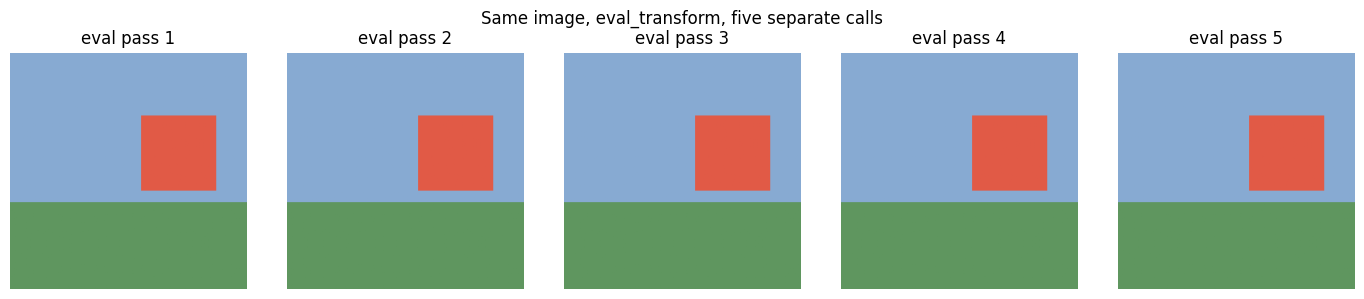

In [7]:
eval_passes = [eval_transform(image) for _ in range(5)]

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for i, (ax, t) in enumerate(zip(axes, eval_passes)):
    ax.imshow(to_displayable(t))
    ax.set_title(f"eval pass {i + 1}")
    ax.axis("off")
fig.suptitle("Same image, eval_transform, five separate calls")
plt.tight_layout()
plt.show()

In [8]:
all_identical = all(torch.equal(eval_passes[0], t) for t in eval_passes[1:])
assert all_identical
print("Confirmed: all 5 evaluation-pipeline outputs are exactly identical.")
print("This is the point of eval_transform: a fixed, reproducible view of")
print("each image, so a validation or test score means the same thing every")
print("time you compute it.")

Confirmed: all 5 evaluation-pipeline outputs are exactly identical.
This is the point of eval_transform: a fixed, reproducible view of
each image, so a validation or test score means the same thing every
time you compute it.


## 5. What each transform contributes, in isolation

Chaining several transforms together makes it easy to lose track of what
any single one is doing. Here each one runs alone, so its individual
effect on the source image is clear before putting the pipeline back
together.

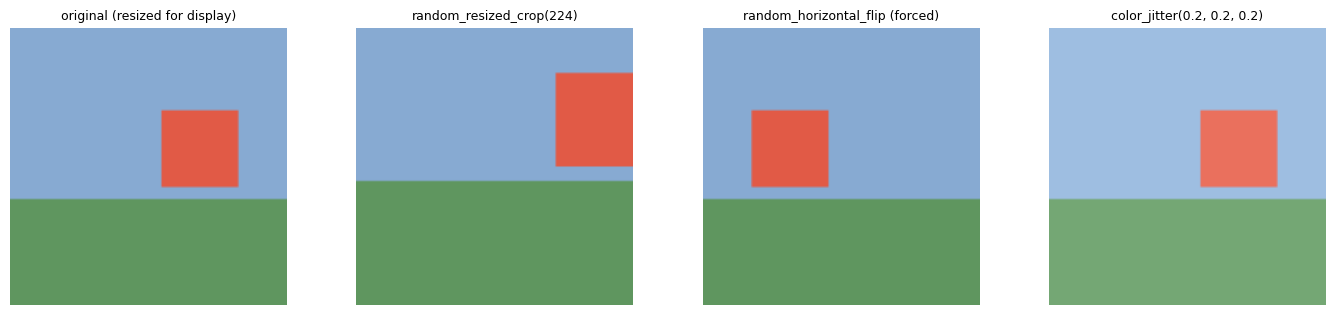

In [9]:
random.seed(2)

resized = image.resize((224, 224), Image.BILINEAR)
individual = {
    "original (resized for display)": resized,
    "random_resized_crop(224)": random_resized_crop(image, 224),
    "random_horizontal_flip (forced)": resized.transpose(Image.FLIP_LEFT_RIGHT),
    "color_jitter(0.2, 0.2, 0.2)": color_jitter(resized, 0.2, 0.2, 0.2),
}

fig, axes = plt.subplots(1, len(individual), figsize=(14, 3.2))
for ax, (title, img) in zip(axes, individual.items()):
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Normalization is not augmentation

The module is explicit about this: normalization does not create variety.
It is a fixed, deterministic rescaling of each colour channel, included in
both pipelines because a pretrained backbone (Part 4) expects input scaled
the same way it was during its own training. We can see this directly by
comparing the per-channel mean and standard deviation of the raw image
tensor against the normalized one.

In [10]:
raw_tensor = to_tensor(image.resize((224, 224), Image.BILINEAR))
normalized_tensor = normalize(raw_tensor, IMAGENET_MEAN, IMAGENET_STD)

print(f"{'channel':>8} | {'raw mean':>9} | {'raw std':>8} | {'normalized mean':>16} | {'normalized std':>15}")
print("-" * 68)
for c, name in enumerate(["R", "G", "B"]):
    raw_mean, raw_std = raw_tensor[c].mean().item(), raw_tensor[c].std().item()
    norm_mean, norm_std = normalized_tensor[c].mean().item(), normalized_tensor[c].std().item()
    print(f"{name:>8} | {raw_mean:>9.4f} | {raw_std:>8.4f} | {norm_mean:>16.4f} | {norm_std:>15.4f}")

print("\nSame image, same crop, same flip; only the channel statistics changed.")
print("Normalization never varies run to run for a fixed input, which is why")
print("it belongs in both the training and evaluation pipelines unchanged.")

 channel |  raw mean |  raw std |  normalized mean |  normalized std
--------------------------------------------------------------------
       R |    0.4965 |   0.1332 |           0.0503 |          0.5816
       G |    0.6125 |   0.0829 |           0.6988 |          0.3700
       B |    0.6087 |   0.2331 |           0.9010 |          1.0359

Same image, same crop, same flip; only the channel statistics changed.
Normalization never varies run to run for a fixed input, which is why
it belongs in both the training and evaluation pipelines unchanged.


## Summary

- Random crop and resize, random horizontal flip, and colour jitter each
  manufacture a label-preserving but pixel-different training example from
  the same source image. Five separate calls to `train_transform` on one
  image confirmed this directly: five different tensors, every pair
  distinct.
- A fixed resize and centre crop, with no random flip or colour jitter,
  give `eval_transform` a single, reproducible view of each image. Five
  separate calls confirmed five byte-for-byte identical tensors.
- Normalization is fixed and deterministic, not an augmentation. It
  belongs in both pipelines unchanged, matching the statistics a
  pretrained backbone was trained with, which Part 4 picks up directly.
- The practical failure mode the module warns about, applying the random
  training pipeline at evaluation time, is exactly what Section 4 above
  would have shown if `eval_transform` had included the random crop, flip,
  or colour jitter steps: the five "identical" passes would silently have
  varied instead, and a validation score computed that way would be noisy
  for no reason tied to the model itself.